# Laboratorio 3 — Generación de Variables Aleatorias Continuas

**Universidad de los Llanos** — Facultad de Ciencias Básicas e Ingenierías — Programa de Ingeniería de Sistemas
**Curso:** Simulación Computacional — **Práctica N.º 03**

**Estudiante:** Miguel Ángel Rincón Morales — Cód. 160005038

Este notebook desarrolla la guía FO-DOC-112 *Generación de Variables Aleatorias Continuas*. Todos los números aleatorios provienen de un generador congruencial mixto implementado a mano (el mismo GLC de $m=2^{48}$ que resultó mejor en el Laboratorio 2); **no se usa ninguna función de aleatoriedad de librería**. De `scipy` sólo se emplean `stats` (pruebas estadísticas y densidades teóricas de referencia), `integrate` (medias teóricas) y `special` (función Gamma).

## 1. Objetivos

- Generar secuencias de valores de una variable aleatoria de una distribución de probabilidad continua.
- Generar valores aleatorios de una distribución continua usando el método de la transformada inversa.
- Generar valores aleatorios de una distribución continua usando el método del rechazo.
- Generar valores aleatorios de una distribución continua usando el método polar para generar variables aleatorias normales.
- Generar valores aleatorios de una distribución exponencial.
- Generar valores aleatorios de una distribución de probabilidad Gamma.
- Generar valores aleatorios de una distribución de probabilidad Normal estándar.
- Generar variables aleatorias de procesos de Poisson y procesos de Poisson no homogéneos.

## 2. Consulta previa

**¿Qué es una variable aleatoria?**
Es una función $X:\Omega\to\mathbb{R}$ que asigna un número real a cada resultado del espacio muestral de un experimento aleatorio. No es una "variable" en el sentido algebraico sino una regla de correspondencia entre sucesos y números; el azar está en el resultado del experimento, no en la regla. Por ejemplo, el tiempo que tarda un servidor en atender a un cliente es una variable aleatoria que toma valores en $(0,\infty)$.

**¿Qué es una distribución de probabilidad?**
Es la descripción completa de cómo se reparte la probabilidad entre los valores posibles de una variable aleatoria. Se caracteriza por la función de distribución acumulada $F(x)=P\{X\le x\}$, que es no decreciente, continua por la derecha, con $F(-\infty)=0$ y $F(\infty)=1$. En el caso discreto se resume con la función de masa $p(x_j)=P\{X=x_j\}$ y en el continuo con la función de densidad $f(x)=F'(x)$.

**¿Cuál es la diferencia entre una distribución discreta y una continua?**
En una distribución discreta la variable toma valores en un conjunto numerable, cada valor tiene probabilidad positiva y $F$ es escalonada. En una continua la variable toma valores en un intervalo no numerable, $P\{X=a\}=0$ para todo $a$, las probabilidades son áreas bajo la densidad, $P\{a<X\le b\}=\int_a^b f(x)\,dx$, y $F$ es continua. Esto cambia el algoritmo de generación: en el caso discreto la transformada inversa busca el intervalo $[F(x_{j-1}),F(x_j))$ que contiene a $U$; en el continuo, cuando $F$ es estrictamente creciente, basta calcular $X=F^{-1}(U)$.

**¿Cuál es la definición de la distribución exponencial?**
Una variable $X$ es exponencial con tasa $\lambda>0$ si $f(x)=\lambda e^{-\lambda x}$ y $F(x)=1-e^{-\lambda x}$ para $x\ge 0$. Cumple $E[X]=1/\lambda$, $\mathrm{Var}(X)=1/\lambda^2$ y la **propiedad de falta de memoria**: $P\{X>s+t\mid X>t\}=P\{X>s\}$. Es la única distribución continua con esa propiedad y por eso los tiempos entre eventos de un proceso de Poisson son exponenciales. Por transformada inversa, $X=-\frac{1}{\lambda}\ln U$.

**¿Cuál es la definición de la distribución Gamma y sus parámetros?**
Una variable $X$ es Gamma con parámetro de forma $\alpha>0$ y tasa $\lambda>0$ si
$$f(x)=\frac{\lambda e^{-\lambda x}(\lambda x)^{\alpha-1}}{\Gamma(\alpha)},\qquad x\ge 0,\qquad \Gamma(\alpha)=\int_0^\infty e^{-y}y^{\alpha-1}\,dy .$$
Cumple $E[X]=\alpha/\lambda$ y $\mathrm{Var}(X)=\alpha/\lambda^2$. Para $\alpha=1$ es la exponencial; para $\alpha=n$ entero es la suma de $n$ exponenciales independientes de tasa $\lambda$ (distribución de Erlang), lo que da un generador directo: $X=-\frac{1}{\lambda}\ln(U_1U_2\cdots U_n)$. Para $\alpha$ no entero no hay forma cerrada de $F^{-1}$ y se usa el método del rechazo.

**¿Cuál es la definición de la distribución normal estándar y sus parámetros?**
La distribución normal $\mathcal{N}(\mu,\sigma^2)$ tiene densidad $f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/(2\sigma^2)}$ con parámetros la media $\mu$ y la desviación estándar $\sigma>0$. La **normal estándar** es el caso $\mu=0$, $\sigma=1$: $\phi(z)=\frac{1}{\sqrt{2\pi}}e^{-z^2/2}$. Cualquier normal se obtiene de una estándar mediante $X=\mu+\sigma Z$. Como $\Phi(z)=\int_{-\infty}^z\phi$ no tiene forma cerrada, no puede usarse la transformada inversa directamente y se recurre al método polar o al método del rechazo.

**¿Qué es un proceso de Poisson y un proceso de Poisson no homogéneo? ¿Cuál es la diferencia?**
Un proceso de Poisson con tasa $\lambda$ es un proceso de conteo $\{N(t),t\ge 0\}$ con $N(0)=0$, incrementos independientes y estacionarios, tal que $N(t+s)-N(s)\sim\text{Poisson}(\lambda t)$. Equivalentemente, los tiempos entre eventos son exponenciales i.i.d. de tasa $\lambda$, lo que da el algoritmo de generación. Un proceso de Poisson **no homogéneo** tiene una función de intensidad $\lambda(t)$ que varía con el tiempo: los incrementos siguen siendo independientes pero **no estacionarios**, y $N(t+s)-N(s)\sim\text{Poisson}\big(m(t+s)-m(s)\big)$ con $m(t)=\int_0^t\lambda(y)\,dy$. La diferencia práctica es que los tiempos entre eventos ya no son exponenciales i.i.d.; para generarlo se usa el método de adelgazamiento (*thinning*): se genera un proceso homogéneo de tasa $\lambda_{\max}\ge\lambda(t)$ y se acepta cada evento en $t$ con probabilidad $\lambda(t)/\lambda_{\max}$.

## 3. Fundamento teórico (resumen)

- **Transformada inversa (Ross, 5.1).** Si $U\sim U(0,1)$ y $F$ es continua y estrictamente creciente, entonces $X=F^{-1}(U)$ tiene distribución $F$, porque $P\{F^{-1}(U)\le x\}=P\{U\le F(x)\}=F(x)$.
- **Método del rechazo (Ross, 5.2).** Para generar $X$ con densidad $f$ se elige una densidad $g$ fácil de simular y una constante $c\ge\sup_x f(x)/g(x)$. Se genera $Y\sim g$ y $U$; se acepta $X=Y$ si $U\le f(Y)/(c\,g(Y))$. El número de iteraciones es geométrico con media $c$.
- **Método polar (Ross, 5.3).** Se generan $V_1,V_2\sim U(-1,1)$ hasta que $S=V_1^2+V_2^2\le 1$; entonces $X=\sqrt{-2\ln S/S}\,V_1$ y $Y=\sqrt{-2\ln S/S}\,V_2$ son normales estándar independientes. La aceptación es $\pi/4$ y evita las funciones trigonométricas de Box–Muller.
- **Proceso de Poisson (Ross, 5.4).** $t=0$; repetir: $t\leftarrow t-\frac{1}{\lambda}\ln U$; si $t>T$ parar, si no registrar $t$.
- **Proceso de Poisson no homogéneo (Ross, 5.5).** Adelgazamiento con cota $\lambda_{\max}$ o, para mayor eficiencia, cotas $\lambda_j$ por subintervalos.

## 4. Equipos y materiales

Google Colaboratory con Python 3 (`numpy`, `matplotlib`, `pandas`, `scipy`) y el Capítulo 5 de [Ross13].

## 5. Procedimiento o metodología

### 5.0 Generador de números pseudoaleatorios

La guía exige usar buenos generadores congruenciales mixtos que cumplan los criterios de uniformidad y aleatoriedad. Se reutiliza el GLC-d del Laboratorio 2 ($a=25214903917$, $c=11$, $m=2^{48}$), que cumple las tres condiciones del teorema de Hull–Dobell (periodo $2^{48}$), y se valida sobre sus primeros 1000 valores con el contraste $\chi^2$ ($k=10$) y el test de rachas, ambos con $\alpha=0{,}05$. Cada ejercicio usa una semilla distinta para trabajar con flujos independientes.

In [1]:
%matplotlib inline
import math, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats, integrate, special

os.makedirs('imagenes', exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
ALPHA = 0.05

# ---------------- Generador congruencial mixto (java.util.Random) ----------------
A, C, M = 25214903917, 11, 2**48

class GLC:
    '''X_{i+1} = (a*X_i + c) mod m ;  u_{i+1} = X_{i+1}/m'''
    def __init__(self, X0, a=A, c=C, m=M):
        self.X, self.a, self.c, self.m = X0, a, c, m
        self.consumidos = 0            # contador de numeros uniformes usados
    def uniforme(self):
        self.X = (self.a * self.X + self.c) % self.m
        self.consumidos += 1
        return self.X / self.m
    def muestra(self, n):
        return np.array([self.uniforme() for _ in range(n)])

# ---------------- Pruebas de uniformidad y aleatoriedad (Laboratorio 2) ----------
def test_chi2(U, k=10, alpha=ALPHA):
    n = len(U)
    O, _ = np.histogram(U, bins=k, range=(0, 1))
    E = n / k
    T = np.sum((O - E) ** 2 / E)
    T_critico = stats.chi2.ppf(1 - alpha, k - 1)
    p_valor = 1 - stats.chi2.cdf(T, k - 1)
    return T, T_critico, p_valor, T <= T_critico

def test_rachas(U, alpha=ALPHA):
    n = len(U)
    S = np.array([0 if U[i - 1] > U[i] else 1 for i in range(1, n)])
    R = 1 + int(np.sum(S[1:] != S[:-1]))
    mu = (2 * n - 1) / 3
    sigma = np.sqrt((16 * n - 29) / 90)
    Z = (R - mu) / sigma
    Z_critico = stats.norm.ppf(1 - alpha / 2)
    return R, Z, Z_critico, abs(Z) <= Z_critico

U = GLC(2391).muestra(1000)
T, Tc, p, uni = test_chi2(U)
R, Z, Zc, ale = test_rachas(U)
print(f'Chi2 = {T:.3f}  (critico {Tc:.3f}, p-valor {p:.4f})  ->  uniforme: {uni}')
print(f'R = {R}, Z = {Z:.3f}  (critico {Zc:.3f})  ->  aleatorio: {ale}')
print(f'Media = {U.mean():.4f} (teorica 0.5), Varianza = {U.var():.4f} (teorica {1/12:.4f})')

Chi2 = 13.740  (critico 16.919, p-valor 0.1319)  ->  uniforme: True
R = 647, Z = -1.451  (critico 1.960)  ->  aleatorio: True
Media = 0.5001 (teorica 0.5), Varianza = 0.0790 (teorica 0.0833)


### 5.1 Generación de variables aleatorias continuas

Para cada apartado se genera una muestra de $n=1000$ valores, se compara el histograma (densidad empírica) con la densidad teórica y se valida con la media muestral frente a la teórica y con la prueba de Kolmogórov–Smirnov contra la $F$ objetivo.

**(a)** $f(x)=\dfrac{e^x}{e-1}$, $0\le x\le 1$. Integrando, $F(x)=\dfrac{e^x-1}{e-1}$; resolviendo $F(x)=U$: $\;X=\ln\big(1+(e-1)U\big)$. *(Transformada inversa.)*

**(b)** $f(x)=\dfrac{x-2}{2}$ en $[2,3]$ y $f(x)=\dfrac{2-x/3}{2}$ en $[3,6]$. Integrando por tramos,
$F(x)=\dfrac{(x-2)^2}{4}$ si $2\le x\le 3$ (con $F(3)=\tfrac14$) y $F(x)=x-\dfrac{x^2}{12}-2$ si $3\le x\le 6$. Invirtiendo:
$$X=\begin{cases}2+2\sqrt{U} & U<\tfrac14\\[3pt] 6-2\sqrt{3(1-U)} & U\ge\tfrac14\end{cases}$$
*(Transformada inversa; más abajo se compara con el método del rechazo.)*

**(c)** $F(x)=\dfrac{x^2+x}{2}$, $0\le x\le 1$ (densidad $f(x)=x+\tfrac12$). De $x^2+x-2U=0$: $\;X=\dfrac{-1+\sqrt{1+8U}}{2}$. *(Transformada inversa.)*

**(d)** Weibull $F(x)=1-\exp(-\alpha x^{\beta})$. De $1-U=\exp(-\alpha X^\beta)$: $\;X=\left(\dfrac{-\ln(1-U)}{\alpha}\right)^{1/\beta}$, con densidad $f(x)=\alpha\beta x^{\beta-1}e^{-\alpha x^\beta}$ y media $\alpha^{-1/\beta}\,\Gamma(1+1/\beta)$. Se usa $\alpha=2$, $\beta=1{,}5$ para la gráfica. *(Transformada inversa.)*

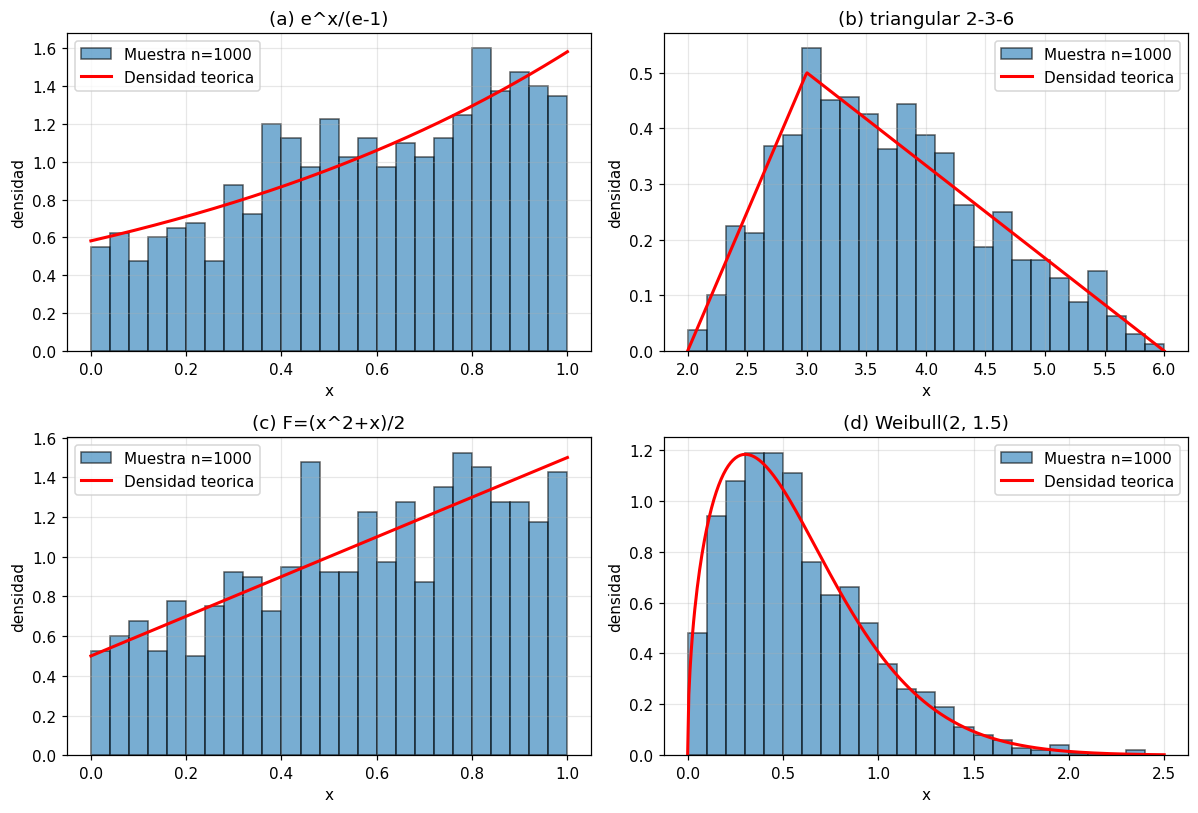

,Distribucion,Media muestral,Media teorica,Desv. muestral,KS D,KS p-valor
0,(a) e^x/(e-1),0.5842,0.5820,0.2734,0.0308,0.2924
1,(b) triangular 2-3-6,3.6704,3.6667,0.8320,0.0229,0.6597
2,(c) F=(x^2+x)/2,0.5774,0.5833,0.2737,0.0255,0.5231
3,"(d) Weibull(2, 1.5)",0.5901,0.5687,0.3898,0.0355,0.1579


In [2]:
# ---------------- Generadores (transformada inversa) ----------------
def gen_a(g):
    return math.log(1 + (math.e - 1) * g.uniforme())

def gen_b(g):
    u = g.uniforme()
    if u < 0.25:
        return 2 + 2 * math.sqrt(u)
    return 6 - 2 * math.sqrt(3 * (1 - u))

def gen_c(g):
    return (-1 + math.sqrt(1 + 8 * g.uniforme())) / 2

def gen_d(g, alpha, beta):
    return (-math.log(1 - g.uniforme()) / alpha) ** (1 / beta)

# ---------------- Densidades y distribuciones teoricas ----------------
f_a = lambda x: np.exp(x) / (math.e - 1)
F_a = lambda x: (np.exp(x) - 1) / (math.e - 1)
def f_b(x):
    x = np.asarray(x, float)
    return np.where((x >= 2) & (x <= 3), (x - 2) / 2, np.where((x > 3) & (x <= 6), (2 - x / 3) / 2, 0.0))
def F_b(x):
    x = np.asarray(x, float)
    return np.where(x < 3, (x - 2) ** 2 / 4, x - x ** 2 / 12 - 2)
f_c = lambda x: x + 0.5
F_c = lambda x: (x ** 2 + x) / 2
AL, BE = 2.0, 1.5
f_d = lambda x: AL * BE * x ** (BE - 1) * np.exp(-AL * x ** BE)
F_d = lambda x: 1 - np.exp(-AL * x ** BE)

N = 1000
muestras = {
    '(a) e^x/(e-1)':          (np.array([gen_a(g) for g in [GLC(2391)] for _ in range(N)]), f_a, F_a, (0, 1)),
    '(b) triangular 2-3-6':   (np.array([gen_b(g) for g in [GLC(29022024)] for _ in range(N)]), f_b, F_b, (2, 6)),
    '(c) F=(x^2+x)/2':        (np.array([gen_c(g) for g in [GLC(7919)] for _ in range(N)]), f_c, F_c, (0, 1)),
    '(d) Weibull(2, 1.5)':    (np.array([gen_d(g, AL, BE) for g in [GLC(4567)] for _ in range(N)]), f_d, F_d, (0, 2.5)),
}

filas = []
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, (nombre, (X, f, F, (lo, hi))) in zip(axes.ravel(), muestras.items()):
    media_teo = integrate.quad(lambda x: x * f(x), lo, hi if nombre[1] != 'd' else np.inf)[0]
    D, p = stats.kstest(X, F)
    filas.append([nombre, X.mean(), media_teo, X.std(ddof=1), D, p])
    ax.hist(X, bins=25, range=(lo, hi), density=True, alpha=0.6, edgecolor='k', label='Muestra n=1000')
    xs = np.linspace(lo, hi, 400)
    ax.plot(xs, f(xs), 'r-', lw=2, label='Densidad teorica')
    ax.set_title(nombre); ax.set_xlabel('x'); ax.set_ylabel('densidad'); ax.legend()
plt.tight_layout(); plt.savefig('imagenes/va_continuas_51.png', bbox_inches='tight'); plt.show()

tabla51 = pd.DataFrame(filas, columns=['Distribucion', 'Media muestral', 'Media teorica', 'Desv. muestral', 'KS D', 'KS p-valor'])
display(tabla51.round(4))

**Extracto de los primeros valores generados en cada apartado**

In [3]:
primeros = pd.DataFrame({k: v[0][:10] for k, v in muestras.items()})
primeros.index = range(1, 11)
display(primeros.round(4))

,(a) e^x/(e-1),(b) triangular 2-3-6,(c) F=(x^2+x)/2,"(d) Weibull(2, 1.5)"
1,0.3134,4.5786,0.7918,0.4106
2,0.8242,3.6160,0.6488,0.3430
3,0.7588,3.5598,0.5436,0.7573
4,0.8351,2.2216,0.4313,0.5706
5,0.8528,4.9682,0.2802,0.8953
6,0.5154,5.1480,0.6312,0.0725
7,0.7586,2.3978,0.3266,0.4196
8,0.9337,2.9824,0.6116,0.8829
9,0.4743,5.1034,0.8812,0.8221
10,0.8093,4.0083,0.1404,0.8227


#### (b) por el método del rechazo (comparación)

La densidad de (b) está acotada por $f(3)=\tfrac12$ sobre un intervalo de longitud 4, así que con $g\sim U(2,6)$ (es decir $g(x)=\tfrac14$) la constante es $c=\sup f/g=\tfrac12\cdot 4=2$: se acepta $Y=2+4U_1$ si $U_2\le f(Y)/\tfrac12$. En promedio se necesitan $c=2$ iteraciones (4 uniformes) por valor, frente a 1 uniforme con la transformada inversa.

In [4]:
def gen_b_rechazo(g):
    while True:
        y = 2 + 4 * g.uniforme()
        if g.uniforme() <= float(f_b(y)) / 0.5:
            return y

g = GLC(12122)
Xb_r = np.array([gen_b_rechazo(g) for _ in range(N)])
D, p = stats.kstest(Xb_r, F_b)
print(f'Rechazo:   media = {Xb_r.mean():.4f}  KS D = {D:.4f} p = {p:.4f}')
print(f'Uniformes consumidos por valor: {g.consumidos / N:.3f}  (teorico 2c = 4);  aceptacion = {N / (g.consumidos / 2):.3f} (teorica 1/c = 0.5)')
Xb_i = muestras['(b) triangular 2-3-6'][0]
print(f'Inversa:   media = {Xb_i.mean():.4f}  (1 uniforme por valor)')
print(f'Media teorica = 11/3 = {11/3:.4f}')

Rechazo:   media = 3.6397  KS D = 0.0277 p = 0.4176
Uniformes consumidos por valor: 3.830  (teorico 2c = 4);  aceptacion = 0.522 (teorica 1/c = 0.5)
Inversa:   media = 3.6704  (1 uniforme por valor)
Media teorica = 11/3 = 3.6667


### 5.1-e Generadores auxiliares: exponencial, Gamma y normal estándar

Estos generadores cubren los objetivos restantes y son la base de las secciones 5.2 y 5.3.

- **Exponencial($\lambda$)**: transformada inversa, $X=-\frac1\lambda\ln(1-U)$ ($1-U$ es también uniforme y evita $\ln 0$).
- **Gamma($n,\lambda$) con $n$ entero**: suma de $n$ exponenciales, $X=-\frac1\lambda\ln(U_1\cdots U_n)$.
- **Gamma($\tfrac32,1$)** (Ross, ejemplo 5d): rechazo con $g$ exponencial de tasa $\tfrac23$ y $c=\dfrac{3^{3/2}}{\sqrt{2\pi e}}\approx 1{,}257$; se acepta $Y$ si $U\le\sqrt{2Y/3}\,e^{1/2-Y/3}$.
- **Normal estándar por el método polar** (Ross, 5.3): genera pares $(X,Y)$ con aceptación $\pi/4\approx 0{,}785$.
- **Normal estándar por rechazo** (Ross, ejemplo 5e): $|Z|$ con densidad $\sqrt{2/\pi}\,e^{-x^2/2}$ se obtiene de $Y_1,Y_2\sim$ Exp(1) aceptando $Y_1$ si $Y_2\ge (Y_1-1)^2/2$ ($c=\sqrt{2e/\pi}\approx1{,}315$); el signo se asigna con una tercera uniforme.

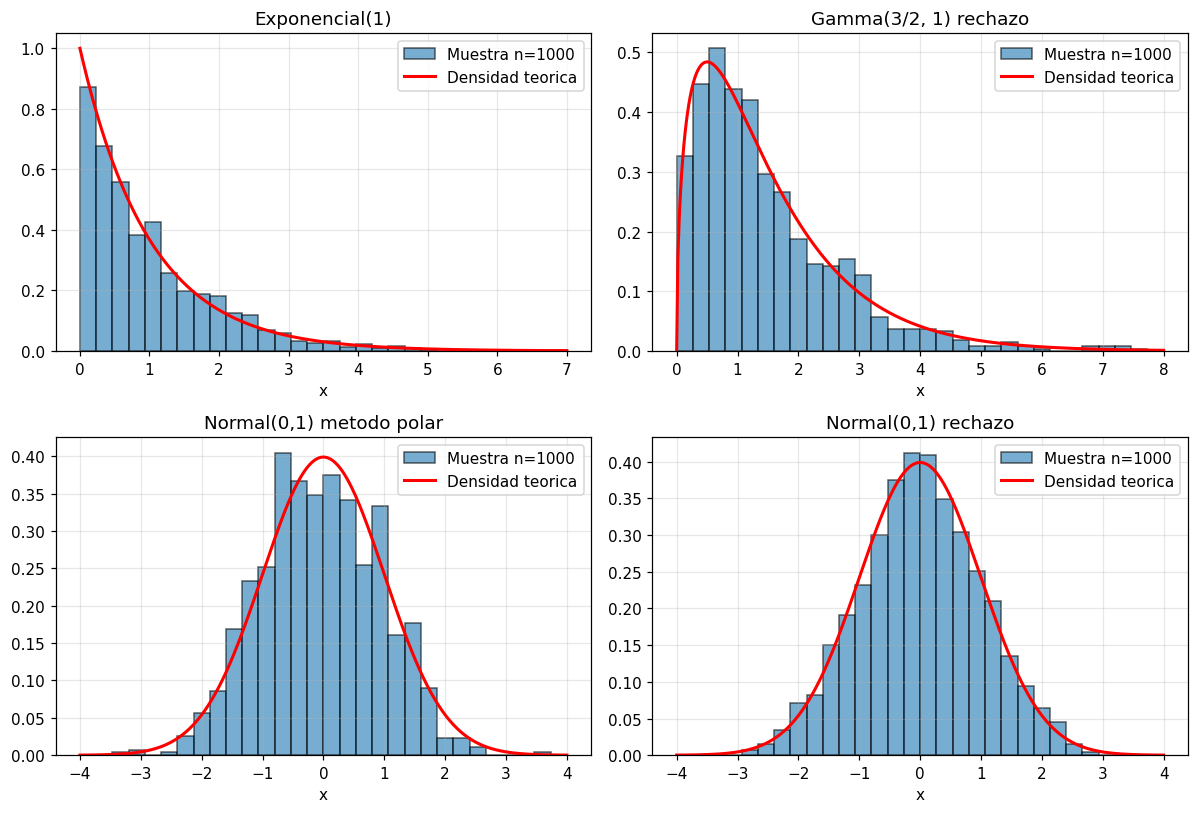

,Distribucion,Media muestral,Media teorica,Var. muestral,Var. teorica,KS D,KS p-valor
0,Exponencial(1),1.0196,1.0,0.9596,1.00,0.0319,0.2546
1,"Gamma(3/2, 1) rechazo",1.4796,1.5,1.4950,1.50,0.0226,0.6766
2,"Normal(0,1) metodo polar",-0.0463,0.0,0.9495,1.00,0.0395,0.0854
3,"Normal(0,1) rechazo",0.0069,0.0,0.9982,1.00,0.0125,0.9973
4,"Gamma(3, 2) suma de exp.",1.4872,1.5,0.7327,0.75,0.0224,0.6908



Eficiencia (uniformes consumidos por valor generado):
  Gamma(3/2) rechazo : 2.516   -> aceptacion 0.795  (teorica 1/c = 0.795)
  Normal polar       : 1.296   -> aceptacion 0.772  (teorica pi/4 = 0.785)
  Normal rechazo     : 3.622   -> aceptacion 0.763  (teorica 1/c = 0.760)


In [5]:
def exponencial(g, lam=1.0):
    return -math.log(1 - g.uniforme()) / lam

def gamma_entera(g, n, lam=1.0):
    prod = 1.0
    for _ in range(n):
        prod *= 1 - g.uniforme()
    return -math.log(prod) / lam

def gamma_32_rechazo(g):
    '''Gamma(3/2, 1) por rechazo con envolvente exponencial de tasa 2/3 (Ross, ej. 5d).'''
    while True:
        y = exponencial(g, 2 / 3)
        if g.uniforme() <= math.sqrt(2 * y / 3) * math.exp(0.5 - y / 3):
            return y

def normal_polar(g):
    '''Devuelve un par de normales estandar independientes (Ross, 5.3).'''
    while True:
        v1, v2 = 2 * g.uniforme() - 1, 2 * g.uniforme() - 1
        s = v1 * v1 + v2 * v2
        if 0 < s <= 1:
            k = math.sqrt(-2 * math.log(s) / s)
            return v1 * k, v2 * k

def normal_rechazo(g):
    '''Normal estandar por rechazo con envolvente exponencial (Ross, ej. 5e).'''
    while True:
        y1, y2 = exponencial(g), exponencial(g)
        if y2 >= (y1 - 1) ** 2 / 2:
            return y1 if g.uniforme() < 0.5 else -y1

gE, gG, gP, gR = GLC(1931), GLC(675248), GLC(7179345), GLC(31415)
X_exp = np.array([exponencial(gE, 1.0) for _ in range(N)])
X_gam = np.array([gamma_32_rechazo(gG) for _ in range(N)])
X_pol = np.array([z for _ in range(N // 2) for z in normal_polar(gP)])
X_rec = np.array([normal_rechazo(gR) for _ in range(N)])
gErl = GLC(8081)
X_erl = np.array([gamma_entera(gErl, 3, 2.0) for _ in range(N)])   # Gamma(3, 2) como suma de exponenciales

conj = [
    ('Exponencial(1)',           X_exp, stats.expon.pdf,                   stats.expon.cdf,                   (0, 7),    1.0, 1.0),
    ('Gamma(3/2, 1) rechazo',    X_gam, stats.gamma(1.5).pdf,              stats.gamma(1.5).cdf,              (0, 8),    1.5, 1.5),
    ('Normal(0,1) metodo polar', X_pol, stats.norm.pdf,                    stats.norm.cdf,                    (-4, 4),   0.0, 1.0),
    ('Normal(0,1) rechazo',      X_rec, stats.norm.pdf,                    stats.norm.cdf,                    (-4, 4),   0.0, 1.0),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
filas = []
for ax, (nombre, X, f, F, (lo, hi), mu, var) in zip(axes.ravel(), conj):
    D, p = stats.kstest(X, F)
    filas.append([nombre, X.mean(), mu, X.var(ddof=1), var, D, p])
    ax.hist(X, bins=30, range=(lo, hi), density=True, alpha=0.6, edgecolor='k', label='Muestra n=1000')
    xs = np.linspace(lo, hi, 400); ax.plot(xs, f(xs), 'r-', lw=2, label='Densidad teorica')
    ax.set_title(nombre); ax.set_xlabel('x'); ax.legend()
plt.tight_layout(); plt.savefig('imagenes/va_auxiliares.png', bbox_inches='tight'); plt.show()

D, p = stats.kstest(X_erl, stats.gamma(3, scale=0.5).cdf)
filas.append(['Gamma(3, 2) suma de exp.', X_erl.mean(), 1.5, X_erl.var(ddof=1), 0.75, D, p])
tabla_aux = pd.DataFrame(filas, columns=['Distribucion', 'Media muestral', 'Media teorica', 'Var. muestral', 'Var. teorica', 'KS D', 'KS p-valor'])
display(tabla_aux.round(4))

print('\nEficiencia (uniformes consumidos por valor generado):')
print(f'  Gamma(3/2) rechazo : {gG.consumidos / N:.3f}   -> aceptacion {N / (gG.consumidos / 2):.3f}  (teorica 1/c = {math.sqrt(2*math.pi*math.e)/3**1.5:.3f})')
print(f'  Normal polar       : {gP.consumidos / N:.3f}   -> aceptacion {(N/2) / (gP.consumidos / 2):.3f}  (teorica pi/4 = {math.pi/4:.3f})')
print(f'  Normal rechazo     : {gR.consumidos / N:.3f}   -> aceptacion {N / ((gR.consumidos - N) / 2):.3f}  (teorica 1/c = {math.sqrt(math.pi/(2*math.e)):.3f})')

### 5.2 Generando procesos de Poisson

#### (a) Primeras $T$ unidades de tiempo de un proceso de Poisson con tasa $\lambda$

Algoritmo (Ross, 5.4): $t=0$, $I=0$; generar $U$ y hacer $t\leftarrow t-\frac1\lambda\ln U$; si $t>T$ parar; si no, $I\leftarrow I+1$, $S(I)=t$ y repetir. Se ilustra con $\lambda=2$ y $T=10$, y se valida con 2000 réplicas: $N(T)$ debe ser Poisson($\lambda T=20$) y los tiempos entre llegadas (las $N(T)+1$ exponenciales generadas en cada réplica, incluida la que cruza $T$) exponenciales de media $1/\lambda=0{,}5$.

Realizacion con lambda=2.0, T=10.0: N(T) = 22 eventos


,Evento,Tiempo S(I),Tiempo entre eventos
0,1,0.1000,0.1000
1,2,0.4268,0.3267
2,3,1.5029,1.0761
3,4,2.2190,0.7161
4,5,2.2621,0.0431
5,6,2.4189,0.1569
6,7,3.1273,0.7084
7,8,3.8436,0.7163
8,9,3.9681,0.1245
9,10,4.6484,0.6803



2000 replicas: media N(T) = 19.938 (teorica 20.0), varianza = 21.732 (teorica 20.0)
Tiempos entre llegadas: media = 0.5008 (teorica 0.5),  KS vs Exp(2.0): p = 0.8953
Chi2 de N(T) vs Poisson(20): 11.597, gl=20, p-valor = 0.9293


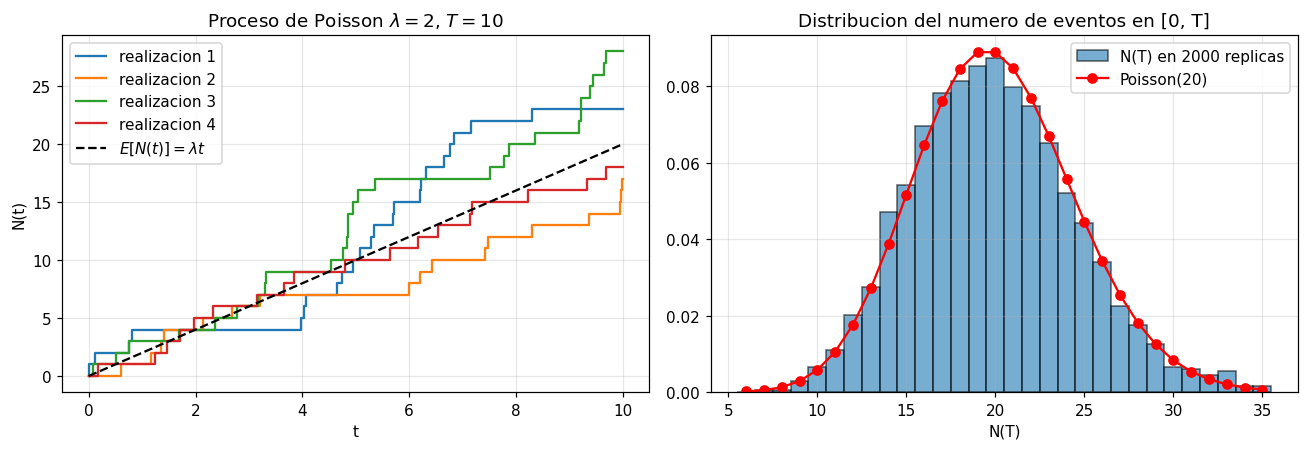

In [6]:
def proceso_poisson(g, lam, T, devolver_ultimo=False):
    t, S = 0.0, []
    while True:
        t += exponencial(g, lam)
        if t > T:
            break
        S.append(t)
    return (np.array(S), t) if devolver_ultimo else np.array(S)

LAM, T = 2.0, 10.0
g = GLC(2024)
S = proceso_poisson(g, LAM, T)
print(f'Realizacion con lambda={LAM}, T={T}: N(T) = {len(S)} eventos')
tabla_pp = pd.DataFrame({'Evento': range(1, len(S) + 1), 'Tiempo S(I)': S.round(4),
                         'Tiempo entre eventos': np.diff(np.r_[0, S]).round(4)})
display(tabla_pp.head(12))

# Validacion con replicas
REP = 2000
gR = GLC(9973)
conteos, entre = [], []
for _ in range(REP):
    s, t_fin = proceso_poisson(gR, LAM, T, devolver_ultimo=True)
    conteos.append(len(s)); entre.extend(np.diff(np.r_[0, s, t_fin]))   # las N(T)+1 exponenciales generadas
conteos, entre = np.array(conteos), np.array(entre)
print(f'\n{REP} replicas: media N(T) = {conteos.mean():.3f} (teorica {LAM*T}), varianza = {conteos.var(ddof=1):.3f} (teorica {LAM*T})')
print(f'Tiempos entre llegadas: media = {entre.mean():.4f} (teorica {1/LAM}),  KS vs Exp({LAM}): p = {stats.kstest(entre, stats.expon(scale=1/LAM).cdf)[1]:.4f}')
# Chi2 de N(T) contra Poisson(20) agrupando colas
ks = np.arange(10, 31); obs = np.array([(conteos == k).sum() for k in ks])
obs[0] += (conteos < 10).sum(); obs[-1] += (conteos > 30).sum()
esp = stats.poisson.pmf(ks, LAM*T) * REP; esp[0] += stats.poisson.cdf(9, LAM*T) * REP; esp[-1] += stats.poisson.sf(30, LAM*T) * REP
chi = ((obs - esp) ** 2 / esp).sum()
print(f'Chi2 de N(T) vs Poisson(20): {chi:.3f}, gl={len(ks)-1}, p-valor = {1 - stats.chi2.cdf(chi, len(ks)-1):.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
g2 = GLC(55)
for r in range(4):
    s = proceso_poisson(g2, LAM, T)
    ax1.step(np.r_[0, s, T], np.r_[0, np.arange(1, len(s) + 1), len(s)], where='post', label=f'realizacion {r+1}')
ax1.plot([0, T], [0, LAM * T], 'k--', label=r'$E[N(t)]=\lambda t$')
ax1.set_xlabel('t'); ax1.set_ylabel('N(t)'); ax1.set_title(r'Proceso de Poisson $\lambda=2$, $T=10$'); ax1.legend()
ax2.hist(conteos, bins=np.arange(5.5, 36.5, 1), density=True, alpha=0.6, edgecolor='k', label=f'N(T) en {REP} replicas')
ax2.plot(np.arange(6, 36), stats.poisson.pmf(np.arange(6, 36), LAM*T), 'ro-', label='Poisson(20)')
ax2.set_xlabel('N(T)'); ax2.set_title('Distribucion del numero de eventos en [0, T]'); ax2.legend()
plt.tight_layout(); plt.savefig('imagenes/proceso_poisson.png', bbox_inches='tight'); plt.show()

#### (b) Variable aleatoria de Coxian

El trabajador completa la etapa $i$ en un tiempo Exp($\lambda_i$) y pasa a la etapa $i+1$ con probabilidad $\alpha_i$ (tras la etapa $k$ el trabajo termina, es decir $\alpha_k=0$). Algoritmo:

> PASO 1: $X=0$, $i=1$.
> PASO 2: Generar $U$ y hacer $X\leftarrow X-\frac{1}{\lambda_i}\ln U$.
> PASO 3: Si $i=k$ terminar. Generar $U'$: si $U'<\alpha_i$, hacer $i\leftarrow i+1$ e ir al paso 2; en caso contrario terminar.

Si $\pi_i=\prod_{j<i}\alpha_j$ es la probabilidad de llegar a la etapa $i$, entonces $E[X]=\sum_{i=1}^k \pi_i/\lambda_i$, y $X$ es una mezcla de hipoexponenciales: con probabilidad $\pi_j(1-\alpha_j)$ el tiempo es la suma de las $j$ primeras exponenciales, cuya densidad (tasas distintas) es $\sum_{i\le j}\lambda_i e^{-\lambda_i x}\prod_{l\ne i}\frac{\lambda_l}{\lambda_l-\lambda_i}$. Se usa $k=3$, $\lambda=(1,\,0{,}5,\,2)$, $\alpha=(0{,}8,\,0{,}6,\,0)$.

Media muestral de X = 2.8372   E[X] teorica = 2.8400


,Etapas completadas,Prob. teorica,Frec. relativa
0,1,0.20,0.2019
1,2,0.32,0.3169
2,3,0.48,0.4812


Integral de la densidad teorica = 1.0000, media = 2.8400


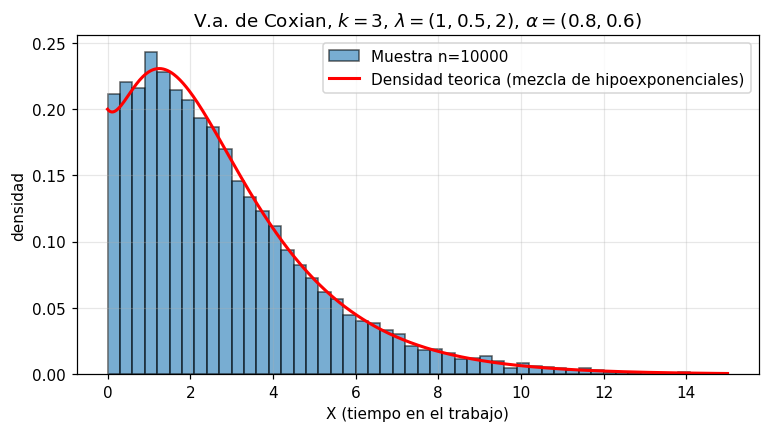

In [7]:
def coxian(g, lam, alpha):
    X, etapas = 0.0, 0
    for i in range(len(lam)):
        X += exponencial(g, lam[i]); etapas += 1
        if g.uniforme() >= alpha[i]:      # con prob. 1-alpha_i deja el trabajo (alpha_k = 0)
            break
    return X, etapas

def dens_hipoexp(x, tasas):
    f = np.zeros_like(x, float)
    for i, li in enumerate(tasas):
        prod = np.prod([lk / (lk - li) for k, lk in enumerate(tasas) if k != i])
        f += li * np.exp(-li * x) * prod
    return f

def dens_coxian(x, lam, alpha):
    f, reach = np.zeros_like(x, float), 1.0
    for j in range(1, len(lam) + 1):
        f += reach * (1 - alpha[j - 1]) * dens_hipoexp(x, lam[:j])
        reach *= alpha[j - 1]
    return f

LAMS, ALPHAS = (1.0, 0.5, 2.0), (0.8, 0.6, 0.0)
g = GLC(1618)
res = [coxian(g, LAMS, ALPHAS) for _ in range(10000)]
Xc = np.array([r[0] for r in res]); Et = np.array([r[1] for r in res])

pi = np.cumprod([1.0] + list(ALPHAS[:-1]))
EX = float(np.sum(pi / np.array(LAMS)))
p_etapas = pi * (1 - np.array(ALPHAS))
print(f'Media muestral de X = {Xc.mean():.4f}   E[X] teorica = {EX:.4f}')
tab = pd.DataFrame({'Etapas completadas': [1, 2, 3], 'Prob. teorica': p_etapas.round(4),
                    'Frec. relativa': [np.mean(Et == j) for j in (1, 2, 3)]})
display(tab)
xs = np.linspace(0, 15, 600)
media_num = integrate.quad(lambda x: x * dens_coxian(np.array([x]), LAMS, ALPHAS)[0], 0, np.inf)[0]
print(f'Integral de la densidad teorica = {integrate.quad(lambda x: dens_coxian(np.array([x]), LAMS, ALPHAS)[0], 0, np.inf)[0]:.4f}, media = {media_num:.4f}')

plt.figure(figsize=(8, 4))
plt.hist(Xc, bins=50, range=(0, 15), density=True, alpha=0.6, edgecolor='k', label='Muestra n=10000')
plt.plot(xs, dens_coxian(xs, LAMS, ALPHAS), 'r-', lw=2, label='Densidad teorica (mezcla de hipoexponenciales)')
plt.xlabel('X (tiempo en el trabajo)'); plt.ylabel('densidad'); plt.title(r'V.a. de Coxian, $k=3$, $\lambda=(1,0.5,2)$, $\alpha=(0.8,0.6)$'); plt.legend()
plt.savefig('imagenes/coxian.png', bbox_inches='tight'); plt.show()

### 5.3 Generando procesos de Poisson no homogéneos

Intensidad $\lambda(t)=t/5$ en $0<t<5$ y $\lambda(t)=1+5(t-5)$ en $5<t<10$ (continua en $t=5$), con $\lambda_{\max}=\lambda(10)=26$ y valor medio $m(t)=\int_0^t\lambda$: $m(t)=t^2/10$ para $t\le5$ y $m(t)=2{,}5+(t-5)+2{,}5(t-5)^2$ para $t\ge5$, de modo que $E[N(5)]=2{,}5$ y $E[N(10)]=70$.

Se implementan dos versiones del método de adelgazamiento (Ross, 5.5):

1. **Básico**: proceso homogéneo de tasa $\lambda_{\max}=26$ en todo $[0,10]$, aceptando cada candidato $t$ con probabilidad $\lambda(t)/26$. Es correcto pero desperdicia trabajo: en $[0,5]$ la intensidad no pasa de 1 y se rechaza el 96 % de los candidatos.
2. **Por subintervalos**: cotas $\lambda_1=1$ en $[0,5]$, $\lambda_2=13{,}5$ en $[5,7{,}5]$ y $\lambda_3=26$ en $[7{,}5,10]$. Gracias a la falta de memoria de la exponencial, el proceso homogéneo de cada subintervalo puede generarse de forma independiente desde su extremo izquierdo.

Basico       : 80 eventos de 264 candidatos (aceptacion 0.303); N(5) = 4
Subintervalos: 71 eventos de 99 candidatos (aceptacion 0.717); N(5) = 4
Primeros 10 tiempos (subintervalos): [0.716  3.0824 3.578  4.8298 5.1298 5.785  5.824  5.8882 5.9003 6.3161]


,Metodo,Media N(10),Var N(10),Media N(5),Candidatos por replica,Aceptacion
0,Basico (lambda_max = 26),70.188,71.588,2.538,260.882,0.269
1,"Subintervalos (1, 13.5, 26)",69.892,71.328,2.516,103.558,0.675
2,Teorico,70.000,70.000,2.500,260.000,NaN


Aceptacion teorica: basico = 70/260 = 0.269;  subintervalos = 70/(5*1 + 2.5*13.5 + 2.5*26) = 0.675


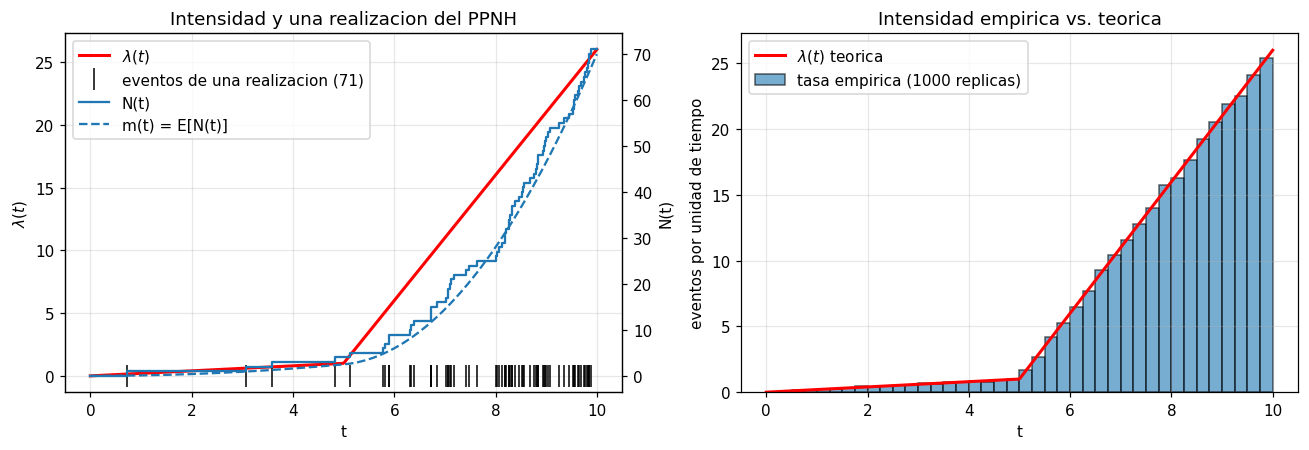

In [8]:
def lam_t(t):
    return t / 5 if t < 5 else 1 + 5 * (t - 5)
def m_t(t):
    return t ** 2 / 10 if t <= 5 else 2.5 + (t - 5) + 2.5 * (t - 5) ** 2

def nhpp_basico(g, lam_fn, lam_max, T):
    t, S, cand = 0.0, [], 0
    while True:
        t += exponencial(g, lam_max)
        if t > T: break
        cand += 1
        if g.uniforme() <= lam_fn(t) / lam_max:
            S.append(t)
    return np.array(S), cand

def nhpp_intervalos(g, lam_fn, bordes, cotas):
    S, cand = [], 0
    for a, b, lm in zip(bordes[:-1], bordes[1:], cotas):
        t = a
        while True:
            t += exponencial(g, lm)
            if t > b: break
            cand += 1
            if g.uniforme() <= lam_fn(t) / lm:
                S.append(t)
    return np.array(S), cand

BORDES, COTAS = [0, 5, 7.5, 10], [1.0, 13.5, 26.0]
g = GLC(777)
S1, c1 = nhpp_basico(g, lam_t, 26.0, 10.0)
g = GLC(777)
S2, c2 = nhpp_intervalos(g, lam_t, BORDES, COTAS)
print(f'Basico       : {len(S1)} eventos de {c1} candidatos (aceptacion {len(S1)/c1:.3f}); N(5) = {(S1 < 5).sum()}')
print(f'Subintervalos: {len(S2)} eventos de {c2} candidatos (aceptacion {len(S2)/c2:.3f}); N(5) = {(S2 < 5).sum()}')
print('Primeros 10 tiempos (subintervalos):', S2[:10].round(4))

# Validacion con replicas
REP = 1000
gB, gI = GLC(1001), GLC(2002)
nB, nI, n5B, n5I, cB, cI, tiempos = [], [], [], [], 0, 0, []
for _ in range(REP):
    s, c = nhpp_basico(gB, lam_t, 26.0, 10.0); nB.append(len(s)); n5B.append((s < 5).sum()); cB += c
    s, c = nhpp_intervalos(gI, lam_t, BORDES, COTAS); nI.append(len(s)); n5I.append((s < 5).sum()); cI += c; tiempos.extend(s)
nB, nI, n5B, n5I, tiempos = map(np.array, (nB, nI, n5B, n5I, tiempos))
resumen = pd.DataFrame({
    'Metodo': ['Basico (lambda_max = 26)', 'Subintervalos (1, 13.5, 26)', 'Teorico'],
    'Media N(10)': [nB.mean(), nI.mean(), m_t(10)],
    'Var N(10)':   [nB.var(ddof=1), nI.var(ddof=1), m_t(10)],
    'Media N(5)':  [n5B.mean(), n5I.mean(), m_t(5)],
    'Candidatos por replica': [cB / REP, cI / REP, np.nan],
    'Aceptacion': [nB.sum() / cB, nI.sum() / cI, np.nan],
})
resumen.loc[2, 'Candidatos por replica'] = 260.0
resumen.loc[2, 'Aceptacion'] = np.nan
display(resumen.round(3))
print(f'Aceptacion teorica: basico = 70/260 = {70/260:.3f};  subintervalos = 70/(5*1 + 2.5*13.5 + 2.5*26) = {70/103.75:.3f}')

# Grafica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ts = np.linspace(0, 10, 500)
ax1.plot(ts, [lam_t(t) for t in ts], 'r-', lw=2, label=r'$\lambda(t)$')
ax1.plot(S2, np.zeros_like(S2), 'k|', ms=14, label=f'eventos de una realizacion ({len(S2)})')
ax1b = ax1.twinx(); ax1b.step(np.r_[0, S2, 10], np.r_[0, np.arange(1, len(S2)+1), len(S2)], where='post', color='C0', label='N(t)')
ax1b.plot(ts, [m_t(t) for t in ts], 'C0--', label='m(t) = E[N(t)]'); ax1b.set_ylabel('N(t)'); ax1b.grid(False)
ax1.set_xlabel('t'); ax1.set_ylabel(r'$\lambda(t)$'); ax1.set_title('Intensidad y una realizacion del PPNH')
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax1b.get_legend_handles_labels(); ax1.legend(h1+h2, l1+l2, loc='upper left')
w = 0.25; bins = np.arange(0, 10 + w, w)
cnt, _ = np.histogram(tiempos, bins=bins)
ax2.bar(bins[:-1], cnt / (REP * w), width=w, align='edge', alpha=0.6, edgecolor='k', label=f'tasa empirica ({REP} replicas)')
ax2.plot(ts, [lam_t(t) for t in ts], 'r-', lw=2, label=r'$\lambda(t)$ teorica')
ax2.set_xlabel('t'); ax2.set_ylabel('eventos por unidad de tiempo'); ax2.set_title('Intensidad empirica vs. teorica'); ax2.legend()
plt.tight_layout(); plt.savefig('imagenes/nhpp.png', bbox_inches='tight'); plt.show()

## 6. Conclusiones

- El GLC de $m=2^{48}$ superó las pruebas de uniformidad y aleatoriedad sobre 1000 valores, de modo que las uniformes usadas en todo el laboratorio son adecuadas.
- La transformada inversa resolvió los cuatro apartados de 5.1 con una sola uniforme por valor, porque en los cuatro casos $F^{-1}$ tiene forma cerrada. Las medias muestrales coincidieron con las teóricas y la prueba KS no rechazó ninguna de las distribuciones objetivo.
- El método del rechazo es la alternativa cuando $F^{-1}$ no es calculable (Gamma no entera, normal) o para evitar funciones costosas; su costo es la constante $c$: aceptación observada cercana a $1/c$ en (b) ($0{,}5$), Gamma($\tfrac32$) ($0{,}795$), polar ($\pi/4$) y normal por rechazo ($0{,}76$).
- El proceso de Poisson generado cumple $N(T)\sim$Poisson($\lambda T$) y tiempos entre llegadas exponenciales; la variable de Coxian reprodujo la media teórica $\sum\pi_i/\lambda_i$ y la mezcla de hipoexponenciales.
- Para el proceso no homogéneo, el adelgazamiento por subintervalos produce la misma distribución que el básico pero con $\approx 104$ candidatos en lugar de 260 por realización, es decir, 2,5 veces menos trabajo.